# Phase 4: Unusual-pattern detection and targeted review

Home Credit application data, KDD Phase 4. The business outcome is early payment difficulty (`TARGET=1`), not a legal default, loss, or fraud label.

Five portfolio-wide detectors look for unusual application patterns from different angles. A sixth item, Phase 2 DBSCAN noise, is available only for the 30,000-row sample and is therefore kept as sampled corroboration rather than a queue vote:

1. IQR (univariate): flags a value outside the whiskers of its own column. Robust on skewed data, calibrated per column from that column's own distribution rather than a fixed rule, but blind to combinations.
2. Z-score (univariate): flags a value far from its column mean, with the cut-off also calibrated per column instead of a fixed number of standard deviations. A sensitive complement to IQR, also blind to combinations.
3. Shrinkage Mahalanobis distance (multivariate, statistical): flags a row whose combination of values is far from the portfolio centre after correlations are considered. Ledoit-Wolf shrinkage keeps the covariance invertible and numerically stable when fields are correlated.
4. Isolation Forest (multivariate, structural): tree-based, no distribution assumption, catches non-linear pockets and interactions that a covariance ellipsoid cannot describe.
5. Local Outlier Factor (multivariate, local density): flags a row whose neighbourhood is far sparser than its neighbours' own neighbourhoods, a relative, local comparison rather than one fixed density rule for the whole portfolio. Two disjoint reference samples are used so every applicant is scored by a novelty model that did not fit that row.
6. DBSCAN noise from Phase 2 (sampled corroboration only): identifies sparse points inside the sampled UMAP view. Because unsampled rows had no chance to receive this flag, it never changes queue admission.

The targeted-review queue has two entry routes. Agreement from at least three of the five portfolio-wide detectors catches unusual combinations. A separate single-axis route catches values at least 10 standard deviations from the processed-feature mean even when the five detectors do not agree. Either route asks a reviewer to verify the record and its business context; neither route diagnoses early payment difficulty or authorises a credit decision.

Primary detector input: `datasets/final/features_anomaly.csv`, which is standardised but not clipped. Record explanations use `features_business.csv`, and `cluster_labels.csv` supplies the sampled DBSCAN corroboration flag.

Outputs land in `results/phase4_anomaly/`: per-method signal tables, the combined evidence table, the targeted-review summary, the record-level investigation CSV, and the plots. The written report lives in the project-root `REPORT.md`.

## 1. Setup and load

In [1]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.stats.stattools import medcouple

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase4_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig_atomic(path, **kwargs):
    # Render beside the target, then replace it. Windows preview and
    # indexing processes can briefly hold an earlier dashboard PNG open.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.tmp{path.suffix}')
    plt.savefig(temp, **kwargs)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

# Unclipped standardized matrix for detection.
FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_anomaly.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None  # None = evaluate every application (full dataset)
CONTAMINATIONS = [0.01, 0.05, 0.10]
DEFAULT_CONTAM = 0.05
MULTI_COL_RULE = 3  # detector signal requires flags in at least 3 fields

assert FEATURES_PATH.exists(), (
    'features_anomaly.csv is missing - re-run src/run_pipeline.py. Phase 4 must '
    'not fall back to the clipped clustering matrix.')

print('Loading unclipped detection features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
assert 'ROW_ID' in labels.columns, 'cluster_labels.csv must contain ROW_ID.'
assert features['ROW_ID'].is_unique and labels['ROW_ID'].is_unique, (
    'ROW_ID must be unique in both feature and label files before alignment.')
if 'SK_ID_CURR' in features.columns and 'SK_ID_CURR' in labels.columns:
    _id_alignment = features[['ROW_ID', 'SK_ID_CURR']].merge(
        labels[['ROW_ID', 'SK_ID_CURR']], on='ROW_ID', how='outer',
        suffixes=('_feature', '_label'), indicator=True)
    _id_mismatch = (
        _id_alignment['_merge'].ne('both') |
        _id_alignment['SK_ID_CURR_feature'].ne(_id_alignment['SK_ID_CURR_label']))
    assert not _id_mismatch.any(), (
        f'SK_ID_CURR alignment failed for {int(_id_mismatch.sum()):,} ROW_ID values; '
        're-run Phase 2 before dropping the duplicate label ID.')
    labels = labels.drop(columns=['SK_ID_CURR'])
df_merged = pd.merge(features, labels, on='ROW_ID', how='inner')
assert len(df_merged) == len(features), (
    f'cluster_labels.csv ({len(labels):,} rows) does not align with features ({len(features):,} rows) - re-run Phase 2!')
cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')
print(f'  merged  : {df_merged.shape}')

label_cols = ['ROW_ID', 'SK_ID_CURR', 'CLUSTER_KMEANS', 'CLUSTER_HIER', 'CLUSTER_DBSCAN', 'IS_OUTLIER']
numeric_cols = [c for c in df_merged.select_dtypes(include=['number']).columns if c not in label_cols]
df_features = df_merged[numeric_cols].copy()
null_pct = df_features.isnull().mean()
drop_cols = null_pct[null_pct > 0.5].index.tolist()
if drop_cols:
    print(f'  dropping {len(drop_cols)} cols >50% null: {drop_cols}')
    df_features = df_features.drop(columns=drop_cols)
df_features = df_features.fillna(df_features.median())

# Confirm the clipping fix actually took effect. On the clipped matrix the
# most extreme financial axes topped out near 2.5 SD; unclipped they run far
# wider, which is what makes a global-extreme category meaningful at all.
_spread = df_features.abs().max().max()
print(f'\nWidest absolute standardized value in the detection matrix: {_spread:.2f} SD')
assert _spread > 4.0, (
    'Detection matrix looks clipped (max |z| <= 4). Phase 4 would be scanning '
    'truncated data and could not find genuine global extremes.')

id_cols = [c for c in ['ROW_ID', 'SK_ID_CURR'] if c in df_merged.columns]
df_numeric = pd.concat([df_merged[id_cols].reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)
df_with_labels = pd.concat([df_numeric, df_merged[['CLUSTER_KMEANS','IS_OUTLIER']].reset_index(drop=True)], axis=1)
df_numeric.to_csv(OUT_DIR / 'data_numeric.csv', index=False)
df_with_labels.to_csv(OUT_DIR / 'data_with_labels.csv', index=False)
print(f'Numeric features: {df_features.shape[1]}')
print('Saved data_numeric.csv & data_with_labels.csv')


Loading unclipped detection features ...


  features: (356255, 44)
  labels  : (356255, 5)
  merged  : (356255, 48)



Widest absolute standardized value in the detection matrix: 426.59 SD


Numeric features: 42
Saved data_numeric.csv & data_with_labels.csv


## 2. Unusual values in individual fields: IQR and Z-score

These checks examine one continuous field at a time, such as income, requested credit, annuity, employment tenure, or an external score. Binary flags and short ordinal fields are excluded because a rare category is not automatically a suspicious financial value. Applying a continuous-data fence to those fields would confuse rarity with evidence for review.

### Why the thresholds are calibrated to this portfolio

A single textbook multiplier does not fit every Home Credit field. Income, requested credit, and annuity have long right tails, so a symmetric rule can over-flag legitimate high values in one field and miss unusual values in another. The skew-adjusted IQR rule therefore allows different upper and lower fences.

For each field, the fence is calibrated to identify roughly the most unusual 1% of values. That 1% is a review-capacity choice, not an estimate of fraud, default, or data-error prevalence. It keeps detector workloads comparable while letting each field supply its own threshold.

Z-score is kept as a second view based on the mean and standard deviation. It uses the same 1% per-field operating point, so differences between the two checks reflect how they respond to skew and tail shape rather than different review volumes.

Some fields have a zero IQR because many applicants share a legitimate value, such as zero card utilisation when there is no card history or an imputed external score when the source is missing. The IQR check abstains on those fields. Otherwise, the presence of credit history could be mistaken for an unusual financial condition.

A row receives a detector signal only when at least three continuous fields are flagged. A separate source-verification route later captures a single value beyond 10 standard deviations, so an isolated extreme value is not lost or mixed into this multi-field rule.

Both checks miss unusual combinations. Income and requested credit may each look common on their own while their relationship indicates affordability pressure. The multivariate checks in the next sections examine those combinations.

In [2]:
# Univariate detectors only make sense on genuinely continuous columns. A
# binary flag or a low-cardinality ordinal breaks the box-plot logic
# outright: if most applicants share one flag value, Q1 and Q3 collapse onto
# it, IQR becomes zero, and every applicant carrying the rarer value (for
# example, simply owning a car) gets flagged as "outside the fence" even
# though it is just an ordinary minority category, not a strange value. The
# same continuous-only feature set is defined once here and reused by the
# Mahalanobis and Local Outlier Factor sections below, so every statistical
# detector reads the same columns.
cont_cols = [c for c in df_numeric.columns
             if c not in ('ROW_ID', 'SK_ID_CURR') and df_numeric[c].nunique() > 10]

TARGET_FLAG_RATE = 0.01  # each column is calibrated to flag about 1% of its own values


def _skew_adjusted_flags(values, mc, iqr, q1, q3, mult):
    if mc >= 0:
        lower = q1 - mult * np.exp(-4 * mc) * iqr
        upper = q3 + mult * np.exp(3 * mc) * iqr
    else:
        lower = q1 - mult * np.exp(-3 * mc) * iqr
        upper = q3 + mult * np.exp(4 * mc) * iqr
    return (values < lower) | (values > upper)


def _calibrate_mult(values, mc, iqr, q1, q3, target_rate, lo=0.05, hi=20.0, iters=50, max_expand=20):
    """
    Binary-search the fence multiplier so this column flags close to
    target_rate of its own values, instead of reusing Tukey's 1.5 (or any
    other textbook constant) for every column regardless of how it behaves.
    A bigger multiplier always widens the fence and can only flag the same
    rows or fewer, so the flagged share is monotonic in the multiplier and
    bisection finds the calibrated value directly. This mirrors the
    empirical 97.5th-percentile cut-off used for Mahalanobis later in this
    notebook: let the data and a chosen operating point set the threshold,
    not a constant borrowed from a different dataset.

    A fixed upper search bound is not always wide enough: a column whose
    interquartile range is tiny relative to its actual spread (a ratio that
    sits within a hair's width of its own median for most applicants, with
    a long thin tail beyond it) needs a far larger multiplier before the
    fence reaches the target rate. Rather than accept whatever the search
    boundary happens to land on, which would silently leave the column
    over-flagged, the upper bound is doubled until it is demonstrably wide
    enough, then the search proceeds as normal.
    """
    rate_hi = _skew_adjusted_flags(values, mc, iqr, q1, q3, hi).mean()
    expand = 0
    while rate_hi > target_rate and expand < max_expand:
        hi *= 4
        rate_hi = _skew_adjusted_flags(values, mc, iqr, q1, q3, hi).mean()
        expand += 1
    for _ in range(iters):
        mid = (lo + hi) / 2
        rate = _skew_adjusted_flags(values, mc, iqr, q1, q3, mid).mean()
        if rate > target_rate:
            lo = mid
        else:
            hi = mid
    # A count-like column (a bounded number of months, refusals, and so on)
    # can only take a small number of distinct flagged-rate values, so the
    # achievable rate sometimes jumps straight past the target instead of
    # passing through it, for example from 5% at one multiplier straight to
    # 0% at the next. Returning hi rather than the midpoint keeps the
    # invariant the bisection already guarantees: hi never flags more than
    # the target rate. Landing under the target on a quantised column is
    # the safe side of that trade-off; landing over it is not.
    return hi


def flag_iqr_adjusted(df, cols, target_rate=TARGET_FLAG_RATE, mc_sample=2000, seed=42):
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    skew_report = {}
    mult_report = {}
    rng = np.random.default_rng(seed)
    for col in cols:
        vals = df[col].values
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        if iqr == 0:
            # A column can pass the nunique > 10 screen and still have
            # Q1 == Q3: a mass point covering more than half the applicants
            # (no credit card means zero utilisation, no bureau record
            # means a zero delay ratio, an imputed bureau score sits at one
            # shared value for everyone missing it). With the middle half
            # collapsed onto one number, IQR has no usable sense of scale,
            # so this column abstains rather than flagging every applicant
            # who differs at all from that shared value.
            skew_report[col] = 0.0
            mult_report[col] = None
            continue
        sample = vals if len(vals) <= mc_sample else rng.choice(vals, size=mc_sample, replace=False)
        mc = float(medcouple(sample))
        mult = _calibrate_mult(vals, mc, iqr, q1, q3, target_rate)
        flags[col] = _skew_adjusted_flags(vals, mc, iqr, q1, q3, mult)
        skew_report[col] = mc
        mult_report[col] = mult
    return flags, skew_report, mult_report


def flag_zscore(df, cols, target_rate=TARGET_FLAG_RATE):
    """
    The naive baseline is calibrated the same way: instead of the textbook
    z > 3 rule (built for a normal distribution most of these columns do
    not follow), each column's threshold is set at the quantile of its own
    |z| distribution that leaves target_rate of applicants beyond it. Both
    univariate methods now operate at the same chosen flag rate, so any
    remaining difference in which rows they catch comes from the statistic
    itself (mean and standard deviation versus median and quartiles), not
    from one method using a stricter cut-off than the other.
    """
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    thr_report = {}
    for col in cols:
        z = np.abs(stats.zscore(df[col], nan_policy='omit'))
        thr = np.quantile(z, 1 - target_rate)
        flags[col] = z > thr
        thr_report[col] = float(thr)
    return flags, thr_report


if SAMPLE_SIZE is None:
    sample = df_numeric.copy().reset_index(drop=True)   # full dataset
else:
    sample = df_numeric.sample(n=min(SAMPLE_SIZE, len(df_numeric)), random_state=RANDOM_SEED).reset_index(drop=True)
row_ids = sample['ROW_ID']
feat_sample = sample.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR'] if c in sample.columns])

print(f'Sample: {len(sample):,} rows x {feat_sample.shape[1]} features')
print(f'Univariate detectors run on {len(cont_cols)} continuous columns, each calibrated to flag '
      f'about {TARGET_FLAG_RATE*100:.0f}% of its own values; '
      f'{feat_sample.shape[1] - len(cont_cols)} binary/ordinal/frequency columns are left to '
      f'Isolation Forest, Local Outlier Factor, and DBSCAN, which handle mixed types natively.')

print('Running skew-adjusted IQR with a calibrated, per-column fence ...')
t0 = time.time()
iqr_flags, skew_report, mult_report = flag_iqr_adjusted(feat_sample, cont_cols)
iqr_count = iqr_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')
most_skewed = sorted(skew_report.items(), key=lambda kv: abs(kv[1]), reverse=True)[:5]
print('  Most skewed continuous columns (medcouple, sample-estimated) and their calibrated fence multiplier:')
for col, mc in most_skewed:
    mult_txt = f'{mult_report[col]:.2f}' if mult_report[col] is not None else 'n/a (zero-width box, abstains)'
    print(f'    {col:32s} MC = {mc:+.3f}   calibrated mult = {mult_txt}')

print('Running Z-score with a calibrated, per-column threshold (naive baseline) ...')
t0 = time.time()
z_flags, z_thr_report = flag_zscore(feat_sample, cont_cols)
z_count = z_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

stats_df = pd.DataFrame({
    'ROW_ID': row_ids,
    'iqr_outlier_count': iqr_count,
    'zscore_outlier_count': z_count,
    'is_iqr_outlier': iqr_count >= MULTI_COL_RULE,
    'is_zscore_outlier': z_count >= MULTI_COL_RULE,
})
stats_df['is_statistical_outlier'] = stats_df['is_iqr_outlier'] | stats_df['is_zscore_outlier']
def get_method(r):
    if r['is_iqr_outlier'] and r['is_zscore_outlier']: return 'Both'
    if r['is_iqr_outlier']: return 'IQR'
    if r['is_zscore_outlier']: return 'Z-score'
    return 'None'
stats_df['statistical_method'] = stats_df.apply(get_method, axis=1)
stats_df.to_csv(OUT_DIR / 'statistical_outliers.csv', index=False)

print(f'\n--- Statistical Summary ---')
print(f'  IQR detector signals (skew-adjusted) : {int(stats_df["is_iqr_outlier"].sum()):,}')
print(f'  Z-score detector signals             : {int(stats_df["is_zscore_outlier"].sum()):,}')
print(f'  Either univariate detector           : {int(stats_df["is_statistical_outlier"].sum()):,}')
print(f'  Both methods                             : {int((stats_df["statistical_method"]=="Both").sum()):,}')

print('\nTop 5 continuous features triggering the adjusted IQR fence:')
print(iqr_flags.sum().sort_values(ascending=False).head(5).to_string())

Sample: 356,255 rows x 42 features
Univariate detectors run on 33 continuous columns, each calibrated to flag about 1% of its own values; 9 binary/ordinal/frequency columns are left to Isolation Forest, Local Outlier Factor, and DBSCAN, which handle mixed types natively.
Running skew-adjusted IQR with a calibrated, per-column fence ...


  Done in 4.2s
  Most skewed continuous columns (medcouple, sample-estimated) and their calibrated fence multiplier:
    OWN_CAR_AGE                      MC = +1.000   calibrated mult = 0.59
    PREV_REFUSED_COUNT               MC = +1.000   calibrated mult = 0.35
    INST_PAYMENT_RATIO_MEAN          MC = -1.000   calibrated mult = 990.69
    CC_MONTHS_COUNT                  MC = +1.000   calibrated mult = 0.63
    INST_DPD_MEAN                    MC = +0.923   calibrated mult = 1.75
Running Z-score with a calibrated, per-column threshold (naive baseline) ...


  Done in 0.8s



--- Statistical Summary ---
  IQR detector signals (skew-adjusted) : 1,295
  Z-score detector signals             : 5,906
  Either univariate detector           : 6,243
  Both methods                             : 958

Top 5 continuous features triggering the adjusted IQR fence:
AMT_CREDIT                     3562
INST_PAYMENT_RATIO_MEAN        3562
AMT_ANNUITY                    3562
ANNUITY_TO_INCOME              3562
BUREAU_DEBT_TO_CREDIT_RATIO    3562


## 3. Isolation Forest: multivariate detection without distribution assumptions

Isolation Forest is an ensemble of random partition trees. A row that is easy to separate from the rest gets isolated in the early splits, so its average path length is short and its score is low.

Why keep it alongside Mahalanobis (next section)? The two make different trade-offs. Mahalanobis measures distance from the portfolio's covariance structure, while Isolation Forest can detect non-linear pockets and unusual interactions without assuming one ellipsoid. Agreement therefore represents two different forms of unusual data geometry.

We run it at three contamination levels (0.01, 0.05, 0.10) as a sensitivity check and select 0.05 as the review-volume operating point. This parameter fixes how many rows the detector flags; it is not an estimated early-payment-difficulty rate.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_sample)
iso_df = pd.DataFrame({'ROW_ID': row_ids})

for c in CONTAMINATIONS:
    print(f'Running Isolation Forest (contamination={c}) ...')
    t0 = time.time()
    iso = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_SEED, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    scores = iso.score_samples(X_scaled)
    iso_df[f'is_isolation_outlier_{c}'] = (preds == -1)
    iso_df[f'isolation_score_{c}'] = scores
    print(f'  Done in {time.time()-t0:.1f}s | detector signals={int((preds==-1).sum())}')

iso_df['is_isolation_outlier'] = iso_df[f'is_isolation_outlier_{DEFAULT_CONTAM}']
iso_df['isolation_score'] = iso_df[f'isolation_score_{DEFAULT_CONTAM}']
iso_df.to_csv(OUT_DIR / 'isolation_forest_outliers.csv', index=False)

print(f'\nSelected operating point (contamination={DEFAULT_CONTAM}): '
      f'{int(iso_df["is_isolation_outlier"].sum()):,} detector signals')
print(f'Score range: {iso_df["isolation_score"].min():.4f} to {iso_df["isolation_score"].max():.4f}')

Running Isolation Forest (contamination=0.01) ...


  Done in 10.5s | detector signals=3563
Running Isolation Forest (contamination=0.05) ...


  Done in 7.3s | detector signals=17813
Running Isolation Forest (contamination=0.1) ...


  Done in 7.1s | detector signals=35626



Selected operating point (contamination=0.05): 17,813 detector signals
Score range: -0.6759 to -0.3586


## 4. Shrinkage Mahalanobis distance: a stable combination check

Euclidean distance treats every feature as independent and equally scaled. Mahalanobis distance instead measures how far a row sits from the portfolio centre after accounting for the way fields move together. It can therefore surface an unusual combination even when no single value is extreme.

Two practical choices matter here.

First, the covariance is estimated with Ledoit-Wolf shrinkage on the full portfolio. The raw sample covariance can be unstable when fields are highly correlated; shrinkage blends it with a well-conditioned target so its inverse remains finite and repeatable. The notebook reports covariance rank, eigenvalue range, shrinkage strength, and condition number before any score is used. This is a numerical-stability choice, not a claim that the portfolio follows a multivariate normal distribution.

Second, the distance uses only the genuinely continuous features, reusing the `cont_cols` set from Section 2. Binary flags and few-valued ordinals can distort a covariance distance, so they remain available to the tree-based detector instead of being forced into this calculation.

The textbook chi-square cut-off assumes multivariate normality, an assumption that is not credible for heavy-tailed and zero-inflated credit fields. It is shown only as a diagnostic. Queue evidence uses an empirical 97.5th-percentile operating point, chosen to keep this detector's review volume comparable with the other multivariate checks. That 2.5% is a workload design choice, not an estimated prevalence of bad data or early payment difficulty.

In [4]:
from sklearn.covariance import LedoitWolf
from scipy.stats import chi2

# Mahalanobis needs an invertible covariance estimate. Binary flags and
# few-valued ordinals can distort that geometry, so this detector uses the
# genuinely continuous columns defined in Section 2. The anomaly feature
# matrix is already standardised by the upstream pipeline.
X_cont = feat_sample[cont_cols].values.astype(np.float64)
print(f'Mahalanobis feature set: {len(cont_cols)} continuous columns '
      f'({feat_sample.shape[1] - len(cont_cols)} binary/ordinal columns excluded, same set as Section 2)')

if not np.isfinite(X_cont).all():
    raise ValueError('Mahalanobis input contains non-finite values.')

# Ledoit-Wolf shrinkage is fitted on the full portfolio. It regularises the
# sample covariance towards a scaled identity target, which keeps the inverse
# stable when features are correlated without introducing sample-to-sample
# variation in the fit population.
print(f'Fitting Ledoit-Wolf covariance on all {len(X_cont):,} rows ...')
t0 = time.time()
mahal_model = LedoitWolf(store_precision=True, assume_centered=False, block_size=1000).fit(X_cont)
print(f'  Done in {time.time()-t0:.1f}s')

# Record conditioning diagnostics before scoring. A finite, positive-definite,
# full-rank covariance is required; the condition number is reported rather
# than hidden behind a successful matrix inversion.
covariance = mahal_model.covariance_
eigenvalues = np.linalg.eigvalsh(covariance)
cov_rank = int(np.linalg.matrix_rank(covariance))
condition_number = float(np.linalg.cond(covariance))
if (not np.isfinite(eigenvalues).all() or eigenvalues.min() <= 0 or
        cov_rank != len(cont_cols) or not np.isfinite(condition_number)):
    raise RuntimeError('Ledoit-Wolf covariance failed the finite, positive-definite, full-rank check.')
print(f'  shrinkage={mahal_model.shrinkage_:.6f} | rank={cov_rank}/{len(cont_cols)} | '
      f'eigenvalues={eigenvalues.min():.3e}..{eigenvalues.max():.3e} | '
      f'condition={condition_number:.3e}')

# Score every row against the shrinkage covariance geometry.
t0 = time.time()
mahal_d2 = mahal_model.mahalanobis(X_cont)
if not np.isfinite(mahal_d2).all():
    raise RuntimeError('Mahalanobis scoring produced non-finite distances.')
print(f'  Scored {len(mahal_d2):,} rows in {time.time()-t0:.1f}s')

# Textbook threshold first, as a demonstration: under normality the squared
# distances are chi-square distributed. The observed flag rate is a diagnostic
# of assumption fit, not evidence that those rows have payment difficulty.
chi2_thr = float(chi2.ppf(0.999, df=len(cont_cols)))
chi2_rate = float((mahal_d2 > chi2_thr).mean()) * 100
print(f'  Chi-square 99.9% threshold (df={len(cont_cols)}) = {chi2_thr:.1f} '
      f'-> diagnostic flag rate {chi2_rate:.1f}%')

# Review-volume cut-off: the empirical top 2.5 percent keeps this detector in
# the same workload range as the other multivariate checks. It is not an
# estimate of error or early-payment-difficulty prevalence.
MAHAL_THR = float(np.quantile(mahal_d2, 0.975))
is_mahal = mahal_d2 > MAHAL_THR
print(f'  Review-volume threshold: empirical 97.5% quantile -> {MAHAL_THR:.3f}')
print(f'  Detector signals: {int(is_mahal.sum()):,} rows ({is_mahal.mean()*100:.2f}%)')

mahal_df = pd.DataFrame({
    'ROW_ID': row_ids.values,
    'mahalanobis_d2': mahal_d2,
    'is_mahalanobis_outlier': is_mahal,
})
mahal_df.to_csv(OUT_DIR / 'mahalanobis_outliers.csv', index=False)
mahal_diagnostics = pd.DataFrame({
    'estimator': ['LedoitWolf'],
    'fit_rows': [len(X_cont)],
    'feature_count': [len(cont_cols)],
    'shrinkage': [float(mahal_model.shrinkage_)],
    'covariance_rank': [cov_rank],
    'min_eigenvalue': [float(eigenvalues.min())],
    'max_eigenvalue': [float(eigenvalues.max())],
    'condition_number': [condition_number],
    'all_scores_finite': [bool(np.isfinite(mahal_d2).all())],
    'chi2_999_threshold': [chi2_thr],
    'chi2_999_diagnostic_flag_rate': [chi2_rate / 100.0],
    'review_quantile': [0.975],
    'review_threshold': [MAHAL_THR],
})
mahal_diagnostics.to_csv(OUT_DIR / 'mahalanobis_diagnostics.csv', index=False)
print('Saved mahalanobis_outliers.csv and mahalanobis_diagnostics.csv')

Mahalanobis feature set: 33 continuous columns (9 binary/ordinal columns excluded, same set as Section 2)
Fitting Ledoit-Wolf covariance on all 356,255 rows ...


  Done in 0.4s
  shrinkage=0.016003 | rank=33/33 | eigenvalues=2.263e-02..3.945e+00 | condition=1.743e+02


  Scored 356,255 rows in 0.3s
  Chi-square 99.9% threshold (df=33) = 63.9 -> diagnostic flag rate 5.1%
  Review-volume threshold: empirical 97.5% quantile -> 92.344
  Detector signals: 8,907 rows (2.50%)


Saved mahalanobis_outliers.csv and mahalanobis_diagnostics.csv


## 5. Local Outlier Factor: a local, density-ratio detector

Mahalanobis asks whether a row fits the correlation shape of the whole portfolio, and Isolation Forest asks how few splits it takes to isolate a row anywhere in the feature space. Local Outlier Factor (LOF) asks a third, genuinely different question: compared with its own nearest neighbours, does this applicant sit in a meaningfully sparser neighbourhood than its neighbours sit in theirs?

A combination can be common in one part of the portfolio and sparse in another. LOF compares each applicant's local density with the density around its nearest neighbours, which helps surface records that do not fit their closest peer group. DBSCAN answers a related but different question with one density rule on the Phase 2 sample. Its noise label is retained only as sampled corroboration; it does not vote in the portfolio-wide review queue.

LOF uses deterministic cross-fitting with two disjoint 20,000-row reference samples. Reference A scores every row outside A, while reference B scores the rows in A. This means each applicant is scored by a novelty model that did not fit that applicant. A compact diagnostic records the two scoring groups and confirms zero fit-row overlap. The top 2.5% of these unseen-row scores form the operating point. This is a workload setting, not an estimate of early payment difficulty or a customer diagnosis.

In [5]:
from sklearn.neighbors import LocalOutlierFactor

LOF_REFERENCE_ROWS = 20000
LOF_NEIGHBORS = 35
n_lof_reference = min(LOF_REFERENCE_ROWS, len(X_cont) // 2)
if n_lof_reference <= LOF_NEIGHBORS:
    raise ValueError('Not enough rows for two disjoint LOF reference sets.')

# A fixed permutation makes the cross-fit reproducible. The two reference
# sets do not overlap. Rows in reference A are scored by model B; every
# other row, including reference B, is scored by model A.
rng_l = np.random.default_rng(RANDOM_SEED)
lof_permutation = rng_l.permutation(len(X_cont))
lof_ref_a = lof_permutation[:n_lof_reference]
lof_ref_b = lof_permutation[n_lof_reference:2 * n_lof_reference]
assert np.intersect1d(lof_ref_a, lof_ref_b).size == 0
lof_in_ref_a = np.zeros(len(X_cont), dtype=bool)
lof_in_ref_a[lof_ref_a] = True

print(f'Fitting two LOF novelty models on disjoint {n_lof_reference:,}-row references ...')
t0 = time.time()
lof_a = LocalOutlierFactor(
    n_neighbors=LOF_NEIGHBORS, novelty=True, metric='euclidean', n_jobs=-1)
lof_b = LocalOutlierFactor(
    n_neighbors=LOF_NEIGHBORS, novelty=True, metric='euclidean', n_jobs=-1)
lof_a.fit(X_cont[lof_ref_a])
lof_b.fit(X_cont[lof_ref_b])
print(f'  Both models fitted in {time.time()-t0:.1f}s')

t0 = time.time()
lof_score = np.empty(len(X_cont), dtype=np.float64)
lof_score[~lof_in_ref_a] = -lof_a.score_samples(X_cont[~lof_in_ref_a])
lof_score[lof_in_ref_a] = -lof_b.score_samples(X_cont[lof_in_ref_a])
if not np.isfinite(lof_score).all():
    raise RuntimeError('LOF cross-fitted scoring produced non-finite values.')
print(f'  Cross-fitted {len(lof_score):,} unseen-row scores in {time.time()-t0:.1f}s')

# This summary makes the no-self-fit property auditable without exporting
# a second row-level file. Every scored row is absent from its scoring
# model's reference set.
lof_group_a = np.flatnonzero(lof_in_ref_a)
lof_group_not_a = np.flatnonzero(~lof_in_ref_a)
lof_seen_overlap_a = int(np.intersect1d(lof_group_a, lof_ref_b).size)
lof_seen_overlap_not_a = int(np.intersect1d(lof_group_not_a, lof_ref_a).size)
lof_crossfit_diagnostic = pd.DataFrame([
    {
        'scored_group': 'Reference A rows',
        'scoring_model': 'LOF fitted on reference B',
        'rows_scored': int(len(lof_group_a)),
        'scoring_reference_rows': int(len(lof_ref_b)),
        'rows_seen_during_scoring_model_fit': lof_seen_overlap_a,
        'unseen_share': 1.0 - lof_seen_overlap_a / len(lof_group_a),
    },
    {
        'scored_group': 'Rows outside reference A',
        'scoring_model': 'LOF fitted on reference A',
        'rows_scored': int(len(lof_group_not_a)),
        'scoring_reference_rows': int(len(lof_ref_a)),
        'rows_seen_during_scoring_model_fit': lof_seen_overlap_not_a,
        'unseen_share': 1.0 - lof_seen_overlap_not_a / len(lof_group_not_a),
    },
])
assert lof_crossfit_diagnostic['rows_scored'].sum() == len(X_cont)
assert lof_crossfit_diagnostic['rows_seen_during_scoring_model_fit'].sum() == 0
assert lof_crossfit_diagnostic['unseen_share'].eq(1.0).all()
lof_crossfit_diagnostic.to_csv(
    OUT_DIR / 'lof_crossfit_diagnostic.csv', index=False)

# The empirical cut-off makes the LOF review volume explicit and repeatable.
# The five detectors still have different flag prevalences and meanings.
LOF_THR = float(np.quantile(lof_score, 0.975))
is_lof = lof_score > LOF_THR
print(f'  Operational threshold: empirical 97.5% quantile -> {LOF_THR:.3f}')
print(f'  Flagged: {int(is_lof.sum()):,} rows ({is_lof.mean()*100:.2f}%)')

lof_df = pd.DataFrame({
    'ROW_ID': row_ids.values,
    'lof_score': lof_score,
    'is_lof_outlier': is_lof,
})
lof_df.to_csv(OUT_DIR / 'lof_outliers.csv', index=False)
print('Saved lof_outliers.csv and lof_crossfit_diagnostic.csv')

Fitting two LOF novelty models on disjoint 20,000-row references ...


  Both models fitted in 5.9s


  Cross-fitted 356,255 unseen-row scores in 24.4s


  Operational threshold: empirical 97.5% quantile -> 1.382
  Flagged: 8,907 rows (2.50%)


Saved lof_outliers.csv and lof_crossfit_diagnostic.csv


## 6. Cross-reference: how many of the five portfolio-wide detectors agree?

Every application receives the same five portfolio-wide checks: skew-adjusted IQR, calibrated Z-score, shrinkage Mahalanobis, Isolation Forest, and Local Outlier Factor. The opportunity to receive each check is the same across the full combined portfolio. The sampled Phase 2 DBSCAN flag is joined only after queue admission as supporting context.

Equal opportunity does not mean equal prevalence. The five detectors surface different shares of the portfolio because their thresholds, statistical assumptions, and views of unusualness differ. The 3-of-5 rule gives each check one vote; it does not make those votes equally prevalent, equally calibrated, or interchangeable in business meaning. The sensitivity table below shows how queue volume changes when the consensus rule and single-axis cut-off move.

### Why the five detectors do not flag the same rows

They disagree because "unusual" is not one concept, and each detector is built to notice a different shape of it:

- Skew-adjusted, calibrated IQR finds an application that is extreme on one field after allowing for that field's own skew and dispersion. For example, an annuity amount can remain outside the calibrated fence even after allowing for the portfolio's legitimate right tail. This is a source-verification signal: the value may be valid or may need correction, and only the underlying record can distinguish those cases.
- Z-score is the naive, symmetry-assuming baseline, calibrated to the same target flag rate as IQR so the comparison is fair. Where a column happens to be close to symmetric it agrees with IQR closely; where a column is heavily skewed, which is most of the continuous financial fields here, it disagrees, either over-flagging the legitimate tail or missing values IQR correctly adjusts for.
- Shrinkage Mahalanobis catches an application whose combination of fields does not fit the way those fields usually move together, even when no single field is extreme. For example, income and requested credit can each sit near their own middle ranges while the combination is uncommon.
- Isolation Forest catches non-linear pockets that a correlation ellipsoid cannot describe. For example, historical card utilisation, instalment delays, and bureau debt can each look ordinary on their own while their specific combination is rare. The detector uses the governed feature matrix, although remaining tenure, asset, and missingness fields may still act as proxies and need separate fairness review.
- Local Outlier Factor catches an application whose neighbourhood is sparser than its neighbours' neighbourhoods. It is a relative local check, not a statement that the application is invalid or risky.
- Phase 2 DBSCAN marks sparse points only inside its 30,000-row UMAP sample. It can corroborate a record already routed for review, but it cannot add a vote because the remaining rows were never eligible for the flag.

The detector count is an evidence band, not a customer verdict:

- 3 or more of 5 detectors: targeted review through detector consensus
- 2 detectors: two-detector signal, not queued unless the separate 10-SD route applies
- 1 detector: one-detector signal, not queued unless the separate 10-SD route applies
- 0 detectors: no portfolio-wide detector flag, though the 10-SD route can still request a source check

The consensus denominator is fixed at five for every row, so available detector count is always 5 and consensus means at least 3 of 5. DBSCAN coverage, DBSCAN noise, and DBSCAN corroboration are exported separately and never affect detector count, agreement share, category, or queue route.

In [6]:
merged_a = pd.merge(stats_df, iso_df[['ROW_ID','is_isolation_outlier','isolation_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, mahal_df[['ROW_ID','is_mahalanobis_outlier','mahalanobis_d2']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, lof_df[['ROW_ID','is_lof_outlier','lof_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(
    merged_a, labels[['ROW_ID','CLUSTER_KMEANS','CLUSTER_DBSCAN','IS_OUTLIER']],
    on='ROW_ID', how='inner')

detector_flag_cols = [
    'is_iqr_outlier', 'is_zscore_outlier', 'is_mahalanobis_outlier',
    'is_isolation_outlier', 'is_lof_outlier']
assert len(detector_flag_cols) == 5 and 'IS_OUTLIER' not in detector_flag_cols
merged_a['detection_count'] = sum(
    merged_a[col].fillna(0).astype(int) for col in detector_flag_cols)
merged_a['available_detector_count'] = 5
merged_a['agreement_share'] = merged_a['detection_count'] / merged_a['available_detector_count']

# DBSCAN had a different eligibility base: only the Phase 2 sample was scored.
# Keep its coverage and noise result as nullable corroboration fields. Neither
# field is allowed into detector count, evidence category, or queue admission.
merged_a['dbscan_sample_covered'] = merged_a['CLUSTER_DBSCAN'].notna()
merged_a['dbscan_sample_noise'] = pd.array(
    np.where(
        merged_a['dbscan_sample_covered'],
        merged_a['IS_OUTLIER'].fillna(0).astype(int).eq(1),
        pd.NA,
    ),
    dtype='boolean',
)

# Second route: a value at least 10 SD from the processed-feature mean on one
# axis. Portfolio-wide consensus is designed for unusual combinations and can
# miss a single extreme field. This separate route requests source verification
# without assuming that the value is wrong or that the customer has payment
# difficulty. It remains separately labelled from detector consensus.
EXTREME_SINGLE_AXIS_Z = 10.0
_detect_ids = [c for c in ['ROW_ID', 'SK_ID_CURR'] if c in df_numeric.columns]
_max_abs_z = df_numeric.drop(columns=_detect_ids).abs().max(axis=1)
merged_a = merged_a.merge(
    pd.DataFrame({'ROW_ID': df_numeric['ROW_ID'], 'max_abs_z': _max_abs_z}),
    on='ROW_ID', how='left')

# Queue-volume sensitivity. Each row can receive all five checks, but the
# checks have different flag prevalences. The grid therefore reports the
# operational effect of changing both admission levers instead of treating
# the selected 3-detector and 10-SD settings as threshold-free truth.
sensitivity_rows = []
for consensus_minimum in [2, 3, 4]:
    _consensus_mask = merged_a['detection_count'] >= consensus_minimum
    for single_axis_z in [8.0, 10.0, 12.0]:
        _single_axis_addition = (
            ~_consensus_mask &
            merged_a['max_abs_z'].fillna(0).ge(single_axis_z))
        _total_queue = _consensus_mask | _single_axis_addition
        sensitivity_rows.append({
            'consensus_at_least': consensus_minimum,
            'single_axis_z_cutoff': single_axis_z,
            'consensus_records': int(_consensus_mask.sum()),
            'single_axis_additions': int(_single_axis_addition.sum()),
            'total_queue': int(_total_queue.sum()),
            'queue_share': float(_total_queue.mean()),
            'vote_interpretation': (
                'Equal opportunity across five checks; detector flag '
                'prevalences and business meanings differ.'),
        })
ensemble_single_axis_sensitivity = pd.DataFrame(sensitivity_rows)
ensemble_single_axis_sensitivity.to_csv(
    OUT_DIR / 'ensemble_single_axis_sensitivity.csv', index=False)
print('Queue sensitivity across 2/3/4 detector votes and 8/10/12 SD:')
print(ensemble_single_axis_sensitivity.drop(
    columns='vote_interpretation').to_string(index=False))
merged_a['extreme_single_axis'] = merged_a['max_abs_z'].fillna(0) >= EXTREME_SINGLE_AXIS_Z

consensus_route = merged_a['detection_count'] >= 3
single_axis_route = (~consensus_route) & merged_a['extreme_single_axis']
merged_a['queue_route'] = np.where(
    consensus_route,
    'Detector consensus',
    np.where(single_axis_route, 'Extreme single-axis value', 'Not queued'))
merged_a['anomaly_category'] = np.select(
    [
        merged_a['queue_route'].ne('Not queued'),
        merged_a['detection_count'].eq(2),
        merged_a['detection_count'].eq(1),
    ],
    ['TARGETED_REVIEW', 'TWO_DETECTOR_SIGNAL', 'ONE_DETECTOR_SIGNAL'],
    default='NO_DETECTOR_FLAG',
)
merged_a['phase2_corroborated'] = (
    merged_a['queue_route'].ne('Not queued') &
    merged_a['dbscan_sample_noise'].fillna(False).astype(bool))

# Method invariants: five equal-opportunity votes for every row; DBSCAN stays
# outside admission and appears only as sampled corroboration.
assert merged_a['available_detector_count'].eq(5).all()
assert merged_a['detection_count'].between(0, 5).all()
assert (merged_a['queue_route'].eq('Detector consensus') == consensus_route).all()
merged_a.to_csv(OUT_DIR / 'anomaly_combined.csv', index=False)

cat_dist = merged_a['anomaly_category'].value_counts()
targeted_review = merged_a[merged_a['anomaly_category'].eq('TARGETED_REVIEW')]
cluster_dist = targeted_review['CLUSTER_KMEANS'].value_counts().sort_index()
corroborated = int(merged_a['phase2_corroborated'].sum())
summary_df = pd.DataFrame({
    'Total_Evaluated': [len(merged_a)],
    'TARGETED_REVIEW': [int(cat_dist.get('TARGETED_REVIEW', 0))],
    'Phase2_Corroborated_DBSCAN': [corroborated],
    'TWO_DETECTOR_SIGNAL': [int(cat_dist.get('TWO_DETECTOR_SIGNAL', 0))],
    'ONE_DETECTOR_SIGNAL': [int(cat_dist.get('ONE_DETECTOR_SIGNAL', 0))],
    'NO_DETECTOR_FLAG': [int(cat_dist.get('NO_DETECTOR_FLAG', 0))],
    'N_IQR': [int(merged_a['is_iqr_outlier'].sum())],
    'N_ZSCORE': [int(merged_a['is_zscore_outlier'].sum())],
    'N_MAHALANOBIS': [int(merged_a['is_mahalanobis_outlier'].sum())],
    'N_ISOFOREST': [int(merged_a['is_isolation_outlier'].sum())],
    'N_LOF': [int(merged_a['is_lof_outlier'].sum())],
    'N_DBSCAN_SAMPLE_COVERED': [int(merged_a['dbscan_sample_covered'].sum())],
    'N_DBSCAN_SAMPLE_NOISE': [int(merged_a['dbscan_sample_noise'].fillna(False).sum())],
    'N_CONSENSUS_ROUTE': [int(merged_a['queue_route'].eq('Detector consensus').sum())],
    'N_SINGLE_AXIS_ROUTE': [int(merged_a['queue_route'].eq('Extreme single-axis value').sum())],
})
print(merged_a['queue_route'].value_counts().to_string())
summary_df.to_csv(OUT_DIR / 'anomaly_summary.csv', index=False)
print(f'Portfolio queue voting: five available detectors for every {len(merged_a):,} rows.')
print(f'DBSCAN sampled coverage: {int(merged_a.dbscan_sample_covered.sum()):,} rows; '
      f'{corroborated:,} already-queued records have sampled DBSCAN corroboration.')
print(cat_dist.to_string())


Queue sensitivity across 2/3/4 detector votes and 8/10/12 SD:
 consensus_at_least  single_axis_z_cutoff  consensus_records  single_axis_additions  total_queue  queue_share
                  2                   8.0               9685                   1754        11439     0.032109
                  2                  10.0               9685                    978        10663     0.029931
                  2                  12.0               9685                    614        10299     0.028909
                  3                   8.0               3980                   3966         7946     0.022304
                  3                  10.0               3980                   2424         6404     0.017976
                  3                  12.0               3980                   1649         5629     0.015800
                  4                   8.0               1501                   5465         6966     0.019553
                  4                  10.0               15

queue_route
Not queued                   349851
Detector consensus             3980
Extreme single-axis value      2424
Portfolio queue voting: five available detectors for every 356,255 rows.
DBSCAN sampled coverage: 30,000 rows; 28 already-queued records have sampled DBSCAN corroboration.
anomaly_category
NO_DETECTOR_FLAG       328870
ONE_DETECTOR_SIGNAL     16722
TARGETED_REVIEW          6404
TWO_DETECTOR_SIGNAL      4259


## 7. Record-level business investigation

The queue size is computed after the corrected five-detector vote. Route A
contains records where at least three of five portfolio-wide detectors agree.
Route B adds remaining records with a value at least 10 SD from the processed
feature mean on one axis. Queue entry means 'review this evidence', not
'early payment difficulty predicted'. Each record is joined to unscaled business
values and reviewed in this order:

1. **Data consistency:** impossible or internally inconsistent values
   are reconciled before underwriting.
2. **Affordability and repayment evidence:** burden, leverage,
   delinquency, utilisation, and bureau history trigger a specific
   human review with the applicant's actual values.
3. **Rare but plausible:** if neither condition is present, rarity is
   documented but is not converted into a risk conclusion.

The executed cell reports the resulting workload by route, review type, and
priority. Sampled DBSCAN noise is shown only as corroboration. Missing history
remains uncertainty rather than bad behaviour, and no queued row is authorised
for an automatic credit decision.


In [7]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.domain_credit import build_anomaly_investigation

business_values = pd.read_csv(PROJECT_ROOT / 'datasets/final/features_business.csv')
investigations, driver_summary = build_anomaly_investigation(
    business=business_values,
    combined=merged_a,
    labels=labels,
    cluster_names=cluster_names_df,
    anomaly_features=df_numeric,
)
investigations.to_csv(OUT_DIR / 'anomaly_investigation.csv', index=False)
driver_summary.to_csv(OUT_DIR / 'anomaly_driver_summary.csv', index=False)

route_counts = investigations['Queue Route'].value_counts()
print(
    f"Targeted review queue: {len(investigations):,} records "
    f"({route_counts.get('Detector consensus', 0):,} detector consensus; "
    f"{route_counts.get('Extreme single-axis value', 0):,} extreme single-axis values)"
)
print('\nReview type distribution:')
print(investigations['Review Type'].value_counts().to_string())
print('\nPriority distribution:')
print(investigations['Priority'].value_counts().to_string())
print('\nEvery row contains applicant-specific evidence and a human-review action.')
print('Automatic Decision Allowed:', investigations['Automatic Decision Allowed'].unique().tolist())


Targeted review queue: 6,404 records (3,980 detector consensus; 2,424 extreme single-axis values)

Review type distribution:
Review Type
Affordability / repayment review    6247
Data consistency check               121
Rare but plausible profile            36

Priority distribution:
Priority
High-priority human review    5766
Targeted human review          475
Urgent data reconciliation      89
Standard review                 74

Every row contains applicant-specific evidence and a human-review action.
Automatic Decision Allowed: ['No']


## 8. Visuals

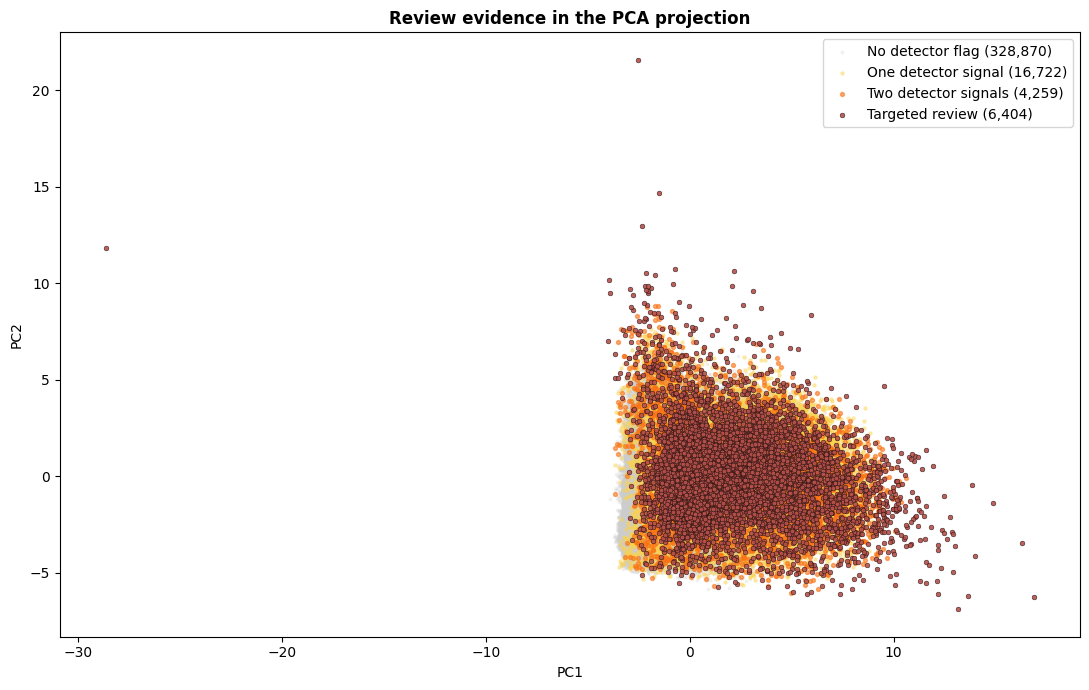

Saved pca_anomaly_sample.csv (35,837 rows for the dashboard)


In [8]:
# PCA scatter showing review-evidence bands
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca.fit_transform(X_scaled)
merged_a_indexed = merged_a.reset_index(drop=True)
merged_a_indexed['PC1'] = X_pca2[:, 0]
merged_a_indexed['PC2'] = X_pca2[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
no_flag = merged_a_indexed[merged_a_indexed['anomaly_category']=='NO_DETECTOR_FLAG']
one_signal = merged_a_indexed[merged_a_indexed['anomaly_category']=='ONE_DETECTOR_SIGNAL']
two_signals = merged_a_indexed[merged_a_indexed['anomaly_category']=='TWO_DETECTOR_SIGNAL']
review = merged_a_indexed[merged_a_indexed['anomaly_category']=='TARGETED_REVIEW']
ax.scatter(no_flag['PC1'], no_flag['PC2'], c='#CCCCCC', s=3, alpha=0.2, label=f'No detector flag ({len(no_flag):,})')
ax.scatter(one_signal['PC1'], one_signal['PC2'], c='#FCD34D', s=5, alpha=0.4, label=f'One detector signal ({len(one_signal):,})')
ax.scatter(two_signals['PC1'], two_signals['PC2'], c='#F97316', s=8, alpha=0.6, label=f'Two detector signals ({len(two_signals):,})')
ax.scatter(review['PC1'], review['PC2'], c='#B4504A', s=12, alpha=0.9, label=f'Targeted review ({len(review):,})', edgecolors='black', linewidths=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Review evidence in the PCA projection', fontweight='bold')
ax.legend()
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_pca_anomaly.png', dpi=150)
plt.show()

# Export every queued record plus a fixed sample of the remaining portfolio.
review_idx = np.where(merged_a_indexed['anomaly_category'] == 'TARGETED_REVIEW')[0]
rng_exp = np.random.default_rng(RANDOM_SEED)
base_idx = rng_exp.choice(len(merged_a_indexed), size=min(30000, len(merged_a_indexed)), replace=False)
keep_idx = np.unique(np.concatenate([base_idx, review_idx]))
merged_a_indexed.iloc[keep_idx][['PC1', 'PC2', 'anomaly_category', 'CLUSTER_KMEANS']].to_csv(
    OUT_DIR / 'pca_anomaly_sample.csv', index=False)
print(f'Saved pca_anomaly_sample.csv ({len(keep_idx):,} rows for the dashboard)')

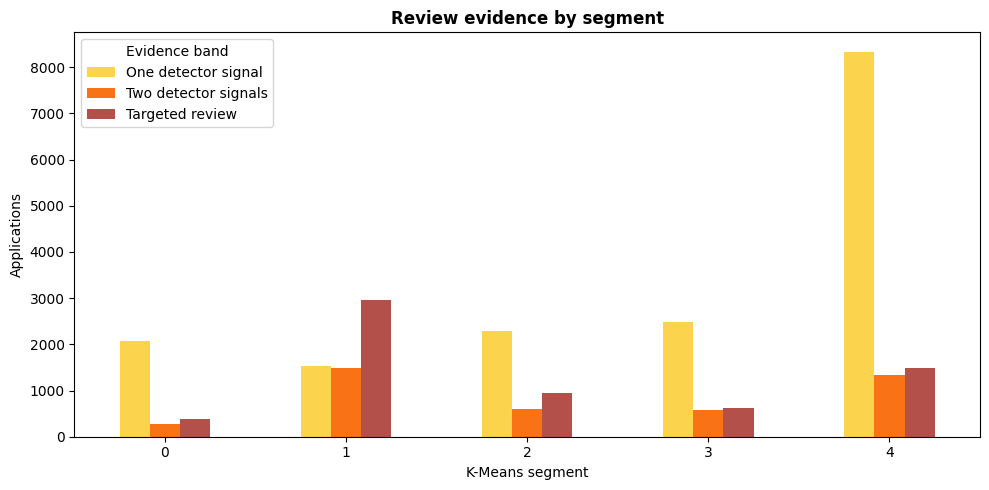

In [9]:
# Review evidence by K-Means segment
cluster_anomalies = merged_a.groupby('CLUSTER_KMEANS')['anomaly_category'].value_counts().unstack(fill_value=0)
if 'NO_DETECTOR_FLAG' in cluster_anomalies.columns:
    cluster_anomalies = cluster_anomalies.drop(columns=['NO_DETECTOR_FLAG'])
cluster_anomalies_sorted = cluster_anomalies.reindex(
    columns=['ONE_DETECTOR_SIGNAL', 'TWO_DETECTOR_SIGNAL', 'TARGETED_REVIEW'],
    fill_value=0,
)
cluster_anomalies_sorted = cluster_anomalies_sorted.rename(columns={
    'ONE_DETECTOR_SIGNAL': 'One detector signal',
    'TWO_DETECTOR_SIGNAL': 'Two detector signals',
    'TARGETED_REVIEW': 'Targeted review',
})
fig, ax = plt.subplots(figsize=(10, 5))
cluster_anomalies_sorted.plot(kind='bar', stacked=False, ax=ax,
                              color=['#FCD34D','#F97316','#B4504A'])
ax.set_xlabel('K-Means segment'); ax.set_ylabel('Applications')
ax.set_title('Review evidence by segment', fontweight='bold')
ax.legend(title='Evidence band')
plt.xticks(rotation=0)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_anomaly_per_cluster.png', dpi=150)
plt.show()

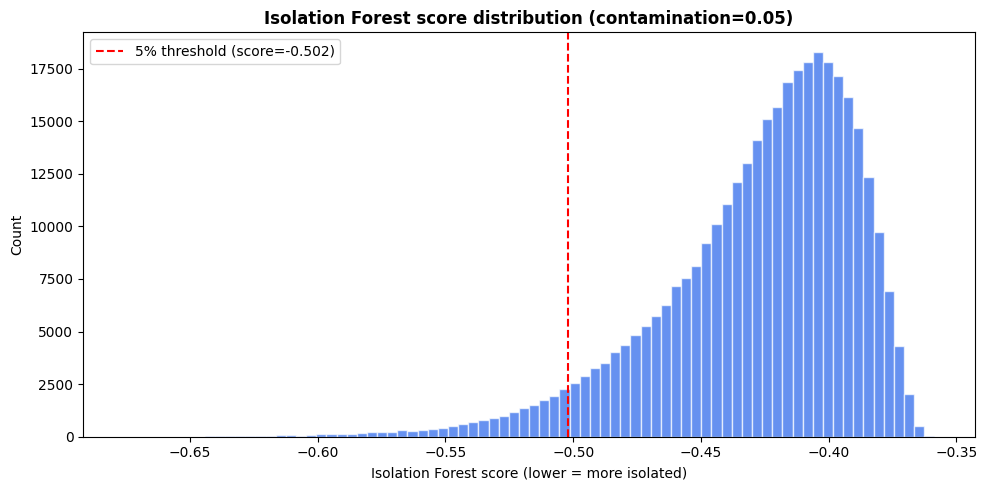

In [10]:
# Isolation Forest score distribution + threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_df['isolation_score'], bins=80, color='#2563EB', alpha=0.7, edgecolor='white')
thr05 = iso_df['isolation_score'].quantile(DEFAULT_CONTAM)
ax.axvline(thr05, color='red', ls='--', label=f'5% threshold (score={thr05:.3f})')
ax.set_xlabel('Isolation Forest score (lower = more isolated)')
ax.set_ylabel('Count')
ax.set_title(f'Isolation Forest score distribution (contamination={DEFAULT_CONTAM})', fontweight='bold')
ax.legend()
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_isolation_score_dist.png', dpi=150)
plt.show()

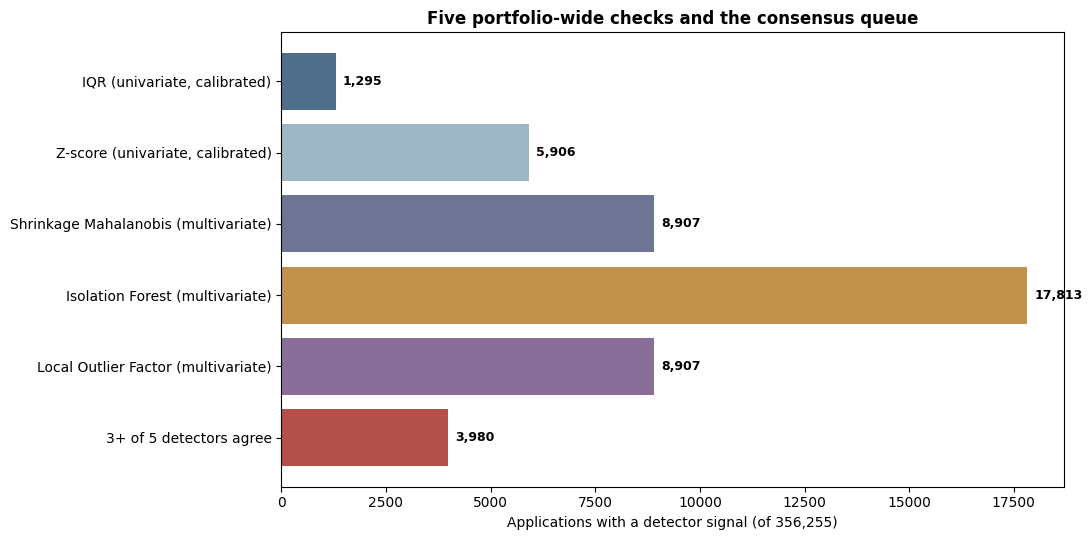

DBSCAN is not in this comparison: 30,000 sampled rows received that separate corroboration check.


In [11]:
# Per-method comparison: how many rows each portfolio-wide check surfaces,
# followed by the number admitted through 3-of-5 consensus.
method_counts = [
    ('IQR (univariate, calibrated)', int(merged_a['is_iqr_outlier'].sum()), '#4E6E8A'),
    ('Z-score (univariate, calibrated)', int(merged_a['is_zscore_outlier'].sum()), '#9FB6C6'),
    ('Shrinkage Mahalanobis (multivariate)', int(merged_a['is_mahalanobis_outlier'].sum()), '#6E7493'),
    ('Isolation Forest (multivariate)', int(merged_a['is_isolation_outlier'].sum()), '#C2914C'),
    ('Local Outlier Factor (multivariate)', int(merged_a['is_lof_outlier'].sum()), '#8A6E9A'),
    ('3+ of 5 detectors agree', int((merged_a['detection_count'] >= 3).sum()), '#B4504A'),
]
fig, ax = plt.subplots(figsize=(11, 5.5))
names_m = [m[0] for m in method_counts]
vals_m = [m[1] for m in method_counts]
cols_m = [m[2] for m in method_counts]
bars = ax.barh(names_m[::-1], vals_m[::-1], color=cols_m[::-1])
for bar, v in zip(bars, vals_m[::-1]):
    ax.text(v + max(vals_m)*0.01, bar.get_y() + bar.get_height()/2, f'{v:,}',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel(f'Applications with a detector signal (of {len(merged_a):,})')
ax.set_title('Five portfolio-wide checks and the consensus queue', fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_method_overlap.png', dpi=150)
plt.show()
print(
    f"DBSCAN is not in this comparison: {int(merged_a.dbscan_sample_covered.sum()):,} sampled rows "
    f"received that separate corroboration check."
)

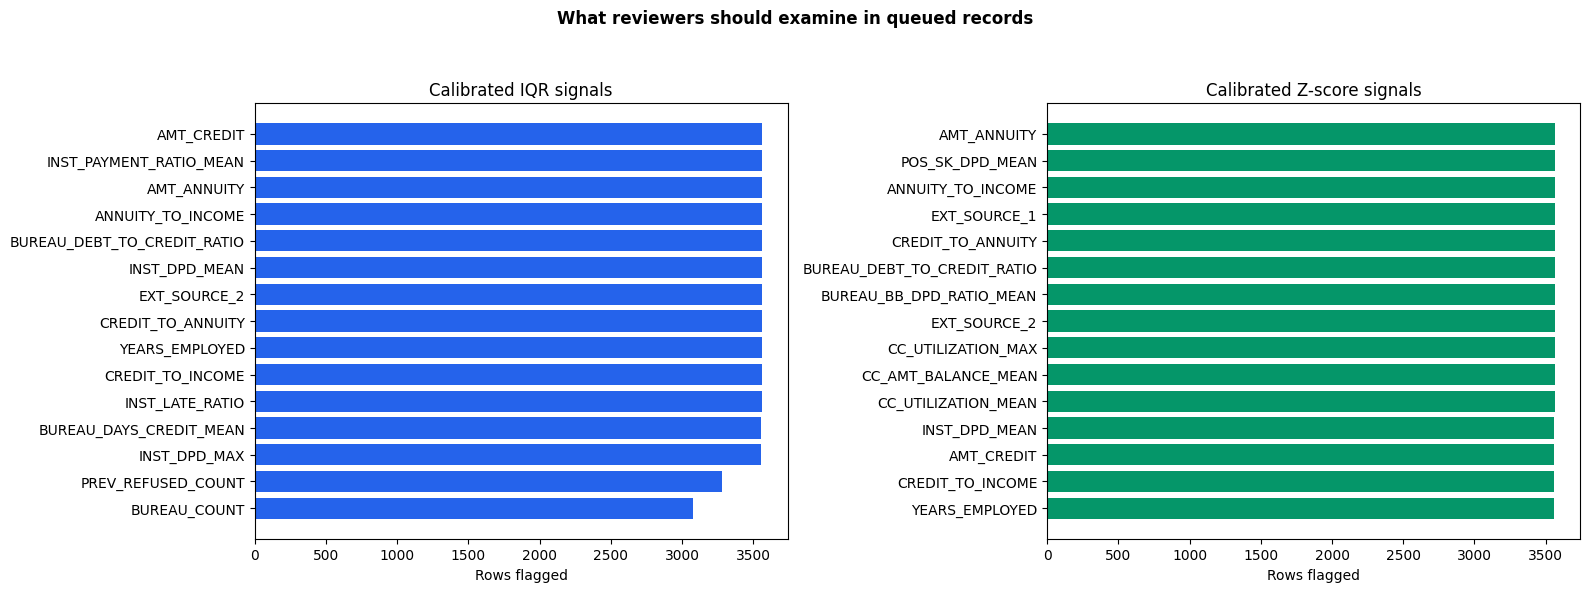

In [12]:
# Business-facing view of which source fields reviewers should verify
top_iqr_feats = iqr_flags.sum().sort_values(ascending=False).head(15)
top_z_feats = z_flags.sum().sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_iqr_feats.index[::-1], top_iqr_feats.values[::-1], color='#2563EB')
fig.suptitle('What reviewers should examine in queued records', fontweight='bold')
axes[0].set_title('Calibrated IQR signals')
axes[0].set_xlabel('Rows flagged')
axes[1].barh(top_z_feats.index[::-1], top_z_feats.values[::-1], color='#059669')
axes[1].set_title('Calibrated Z-score signals')
axes[1].set_xlabel('Rows flagged')
plt.tight_layout(rect=[0, 0, 1, 0.94])
savefig_atomic(OUT_DIR / 'plot_anomaly_heatmap.png', dpi=150)
plt.show()

---
Phase 4 done. The artefacts are in `results/phase4_anomaly/`.

---
## 9. Business drivers and detector agreement

Counts alone do not explain the review workload. The first view groups the
business reasons for review; the second shows whether checks surface the same
records. Agreement supports review priority, but it does not predict early
payment difficulty. DBSCAN comparisons use only its Phase 2 sample.


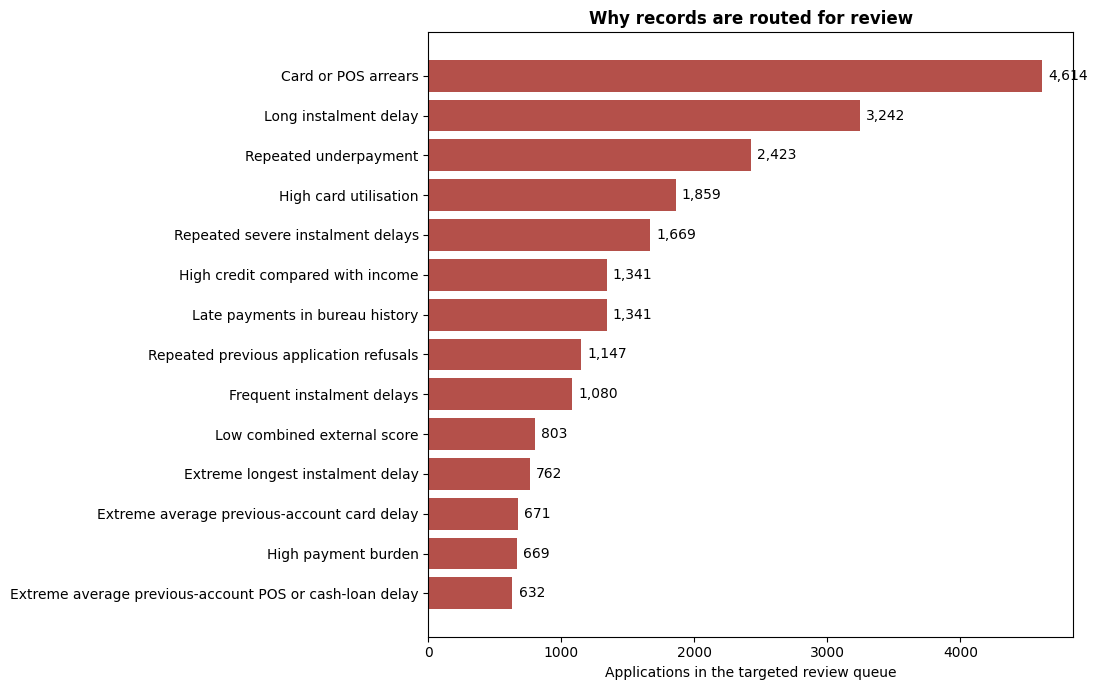

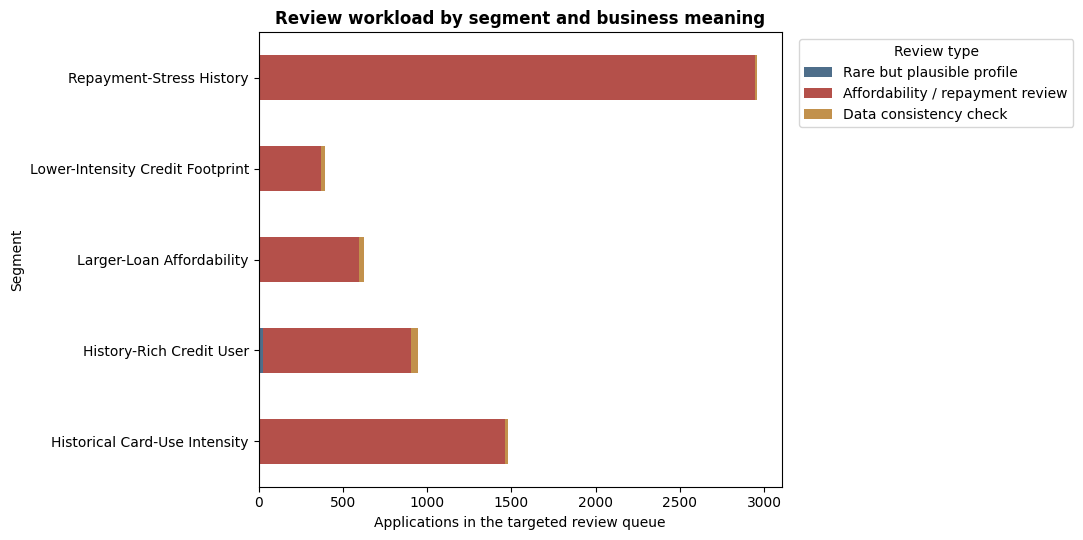

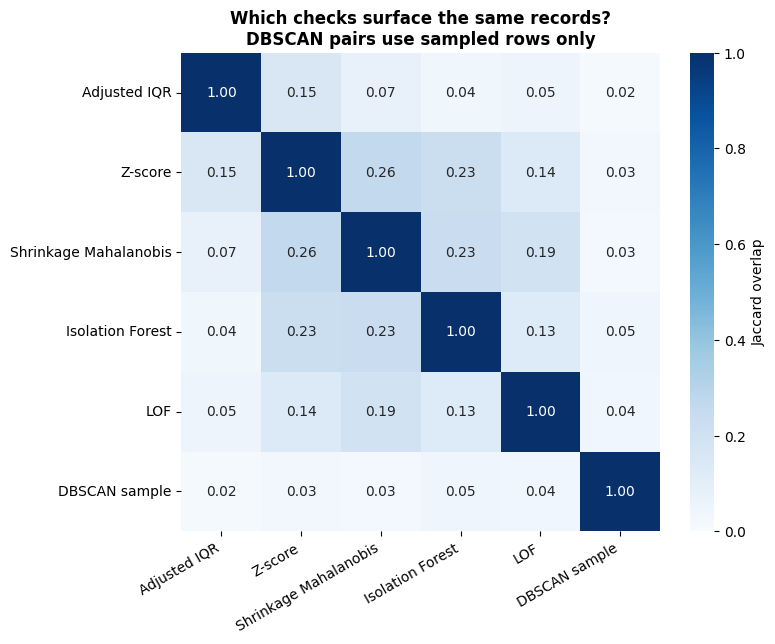

In [13]:
import seaborn as sns

top_drivers = driver_summary.head(14).sort_values('records')
fig, ax = plt.subplots(figsize=(11, 7))
colors = top_drivers['Review Type'].map({
    'Data consistency check': '#C2914C',
    'Affordability / repayment review': '#B4504A',
    'Rare but plausible profile': '#4E6E8A',
}).fillna('#6B7280')
bars = ax.barh(top_drivers['Driver'], top_drivers['records'], color=colors)
for bar, value in zip(bars, top_drivers['records']):
    ax.text(value + max(top_drivers['records']) * .01,
            bar.get_y() + bar.get_height()/2, f'{value:,}', va='center')
ax.set_xlabel('Applications in the targeted review queue')
ax.set_title('Why records are routed for review', fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_anomaly_business_drivers.png', dpi=170, bbox_inches='tight')
plt.show()

review_by_segment = pd.crosstab(investigations['Segment'], investigations['Review Type'])
review_by_segment.to_csv(OUT_DIR / 'anomaly_review_by_segment.csv')
fig, ax = plt.subplots(figsize=(11, 5.5))
order = ['Rare but plausible profile', 'Affordability / repayment review', 'Data consistency check']
use = [c for c in order if c in review_by_segment.columns]
review_by_segment[use].plot(kind='barh', stacked=True, ax=ax,
    color=['#4E6E8A', '#B4504A', '#C2914C'][:len(use)])
ax.set_xlabel('Applications in the targeted review queue'); ax.set_ylabel('Segment')
ax.set_title('Review workload by segment and business meaning', fontweight='bold')
ax.legend(title='Review type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_anomaly_review_by_segment.png', dpi=170, bbox_inches='tight')
plt.show()

detector_cols = [
    ('Adjusted IQR', 'is_iqr_outlier', False),
    ('Z-score', 'is_zscore_outlier', False),
    ('Shrinkage Mahalanobis', 'is_mahalanobis_outlier', False),
    ('Isolation Forest', 'is_isolation_outlier', False),
    ('LOF', 'is_lof_outlier', False),
    ('DBSCAN sample', 'dbscan_sample_noise', True),
]
detector_names = [item[0] for item in detector_cols]
overlap = pd.DataFrame(index=detector_names, columns=detector_names, dtype=float)
overlap_denominators = []
portfolio_mask = pd.Series(True, index=merged_a.index)
for name_a, col_a, sampled_a in detector_cols:
    for name_b, col_b, sampled_b in detector_cols:
        comparison_mask = (
            merged_a['dbscan_sample_covered'] if sampled_a or sampled_b else portfolio_mask
        )
        a = merged_a.loc[comparison_mask, col_a].fillna(False).astype(bool)
        b = merged_a.loc[comparison_mask, col_b].fillna(False).astype(bool)
        intersection = int((a & b).sum())
        union = int((a | b).sum())
        overlap.loc[name_a, name_b] = intersection / union if union else 0.0
        overlap_denominators.append({
            'check_a': name_a, 'check_b': name_b,
            'eligible_rows': int(comparison_mask.sum()),
            'intersection_rows': intersection, 'jaccard_union_rows': union,
            'jaccard_overlap': overlap.loc[name_a, name_b],
        })
overlap.to_csv(OUT_DIR / 'detector_jaccard_overlap.csv')
pd.DataFrame(overlap_denominators).to_csv(
    OUT_DIR / 'detector_jaccard_overlap_denominators.csv', index=False)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(overlap.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Jaccard overlap'}, ax=ax)
ax.set_title('Which checks surface the same records?\nDBSCAN pairs use sampled rows only',
             fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_detector_agreement_heatmap.png', dpi=170, bbox_inches='tight')
plt.show()


---
## 10. Threshold sensitivity

The assignment requires IQR, Z-score, and Isolation Forest. Conventional
textbook thresholds are shown beside the skew-adjusted/calibrated operating
choices so the queue is not presented as threshold-free truth. A detector's
selected review volume is an analytical choice, not evidence that a customer
will experience early payment difficulty.


In [14]:
conventional_iqr = pd.DataFrame(False, index=feat_sample.index, columns=cont_cols)
conventional_z = pd.DataFrame(False, index=feat_sample.index, columns=cont_cols)
for col in cont_cols:
    values = feat_sample[col]
    q1, q3 = values.quantile([.25, .75]); iqr = q3 - q1
    if iqr > 0:
        conventional_iqr[col] = (values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)
    z = np.abs(stats.zscore(values, nan_policy='omit'))
    conventional_z[col] = z > 3
threshold_sensitivity = pd.DataFrame([
    {'detector': 'IQR conventional 1.5x; 3+ columns',
     'records': int((conventional_iqr.sum(axis=1) >= MULTI_COL_RULE).sum())},
    {'detector': 'Adjusted IQR calibrated; 3+ columns',
     'records': int(stats_df['is_iqr_outlier'].sum())},
    {'detector': 'Z-score conventional |z|>3; 3+ columns',
     'records': int((conventional_z.sum(axis=1) >= MULTI_COL_RULE).sum())},
    {'detector': 'Z-score empirical 99th percentile; 3+ columns',
     'records': int(stats_df['is_zscore_outlier'].sum())},
] + [
    {'detector': f'Isolation Forest contamination {c:.0%}',
     'records': int(iso_df[f"is_isolation_outlier_{c}"].sum())}
    for c in CONTAMINATIONS
])
threshold_sensitivity['share'] = threshold_sensitivity['records'] / len(feat_sample)
threshold_sensitivity.to_csv(OUT_DIR / 'anomaly_threshold_sensitivity.csv', index=False)
print(threshold_sensitivity.to_string(index=False))


                                     detector  records    share
            IQR conventional 1.5x; 3+ columns    68297 0.191708
          Adjusted IQR calibrated; 3+ columns     1295 0.003635
       Z-score conventional |z|>3; 3+ columns     8199 0.023014
Z-score empirical 99th percentile; 3+ columns     5906 0.016578
            Isolation Forest contamination 1%     3563 0.010001
            Isolation Forest contamination 5%    17813 0.050001
           Isolation Forest contamination 10%    35626 0.100001
